In [1]:
!git clone https://github.com/Felix-Schwer/rainfall_kf.git
#!git pull
%cd /content/rainfall_kf
!pip install -e .

fatal: destination path 'rainfall_kf' already exists and is not an empty directory.
/content/rainfall_kf
Obtaining file:///content/rainfall_kf
  Preparing metadata (setup.py) ... done
  Attempting uninstall: rainfall_kf
    Found existing installation: rainfall_kf 0.1.0
    Uninstalling rainfall_kf-0.1.0:
      Successfully uninstalled rainfall_kf-0.1.0
  Running setup.py develop for rainfall_kf


In [2]:
import numpy as np
from rainfall_kf.models.lorenz import LorenzParameters, LorenzTransition, LorenzObservation
from rainfall_kf.enkf import EnsembleKalmanFilter

DT = 0.01
times = np.arange(0, 2, DT)
sim_state0 = np.array([[1.0], [1.0], [1.0]])
lorenz_params = LorenzParameters()

sim_obs = np.empty((2, len(times)))
state  = sim_state0
for i, t in enumerate(times):
    state = LorenzTransition(state, lorenz_params, dt=DT) + 0.1 * np.random.randn(3, 1)  # Add process noise to the true state
    sim_obs[:, i] = (LorenzObservation(state) + 0.1 * np.random.randn(2, 1)).flatten()

In [3]:
enkf = EnsembleKalmanFilter(TransitionEquation=lambda states: LorenzTransition(states, lorenz_params, dt=DT),
                           ObservationEquation=LorenzObservation,
                           Q=np.diag([0.1, 0.1, 0.1]),
                           R=np.diag([0.1, 0.1]))

initial_ensemble = sim_state0 + 0.1 * np.random.randn(3, 100)  # Perturb initial state to create ensemble

result = enkf.run(initial_ensemble=initial_ensemble, times=times, observations=sim_obs)

Text(0.5, 0, 'Time')

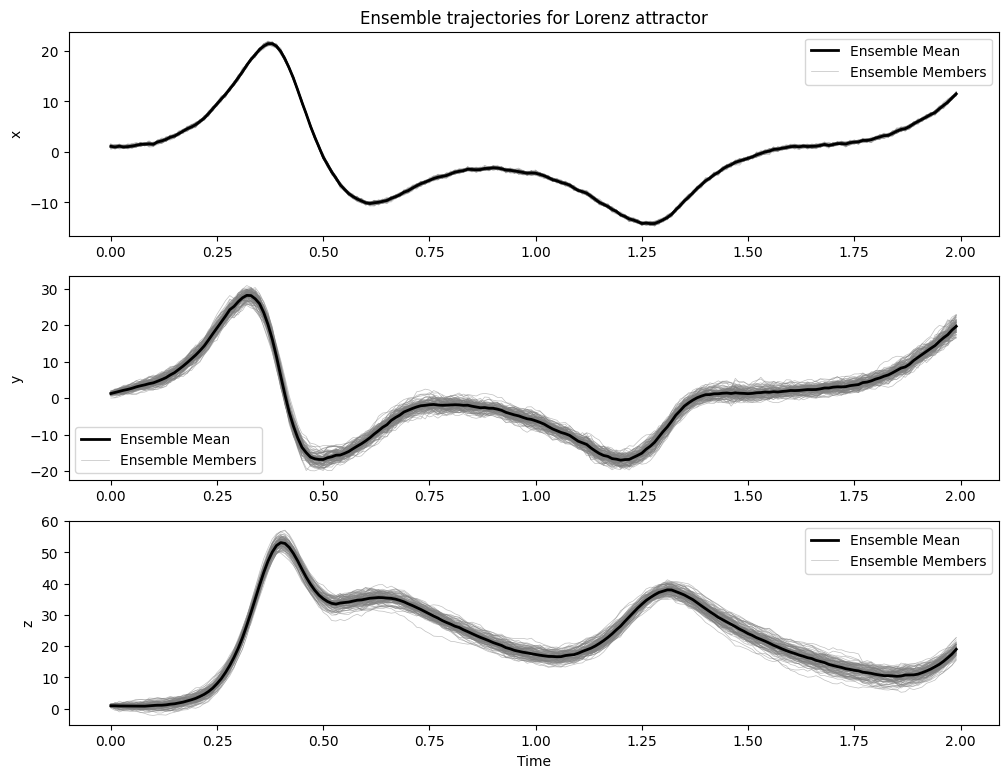

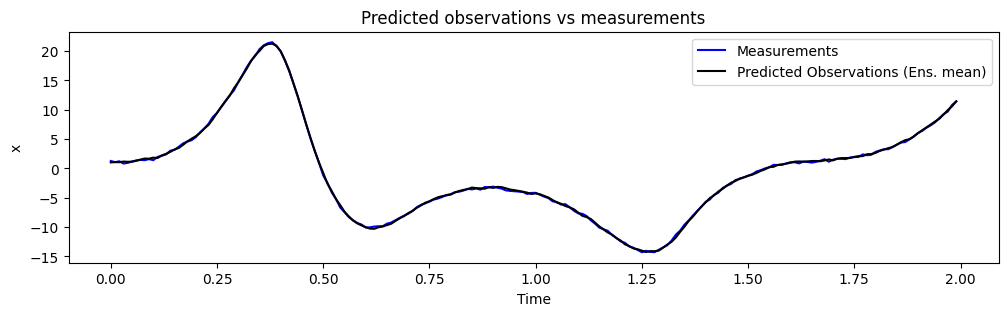

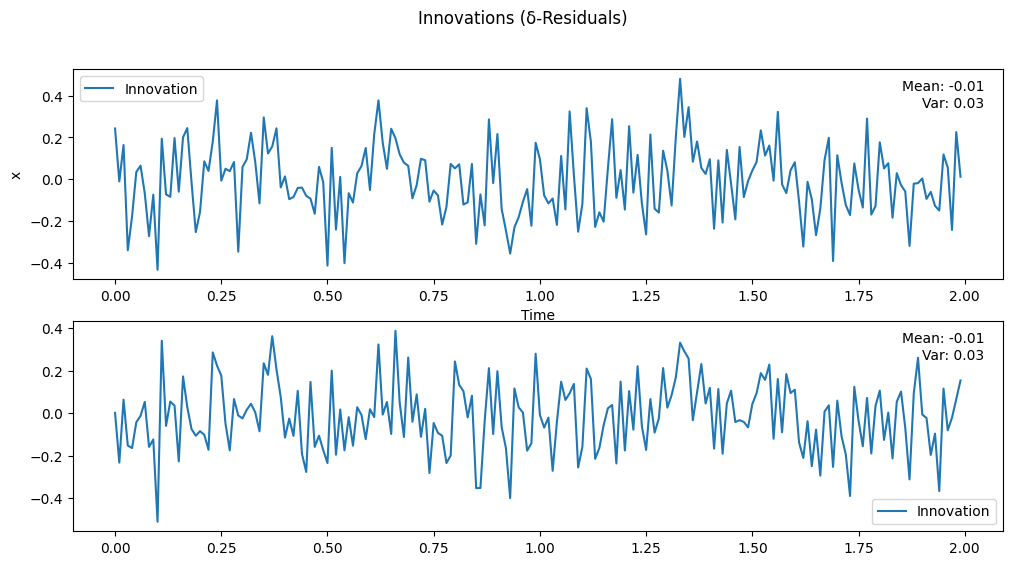

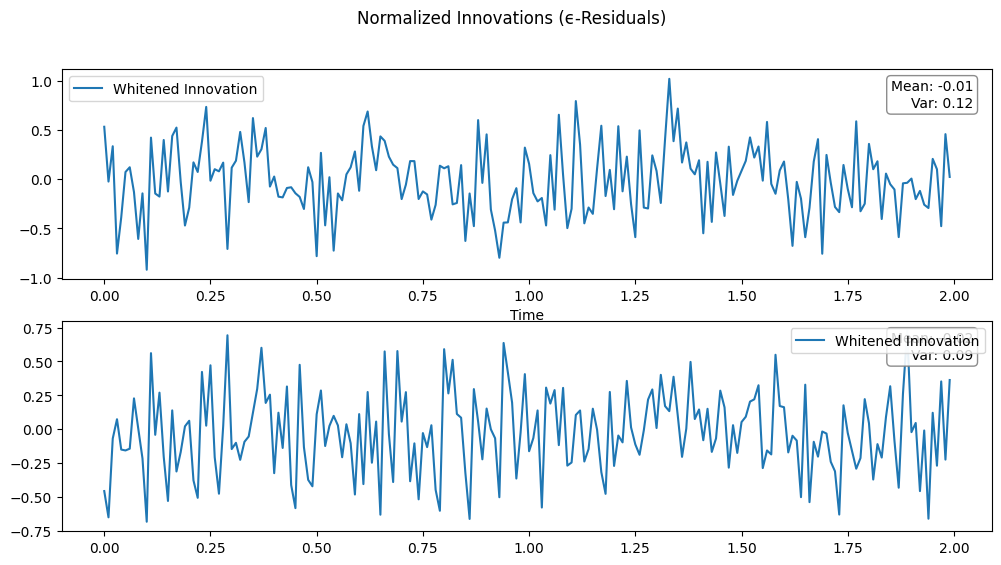

In [5]:
fig = result.plot_ensembles()
axes  = fig.get_axes()
axes[0].set_title("Ensemble trajectories for Lorenz attractor")
axes[2].set_xlabel("Time")
axes[0].set_ylabel("x")
axes[1].set_ylabel("y")
axes[2].set_ylabel("z")

fig = result.plot_observations()
ax = fig.get_axes()[0]
ax.set_title("Predicted observations vs measurements")
ax.set_xlabel("Time")
ax.set_ylabel("x")

fig = result.plot_innovations()
ax = fig.get_axes()[0]
ax.set_ylabel("x")
ax.set_xlabel("Time")

fig = result.plot_whitened_innovations()
ax = fig.get_axes()[0]
ax.set_xlabel("Time")